# 🚗 Tesla EV Sales — End-to-End ML Pipeline
## Data Science Assignment | 2015–2025 Dataset

**Objective:** Build a complete, production-style ML pipeline on Tesla's worldwide delivery and price data.

### Pipeline Stages
| # | Stage | Description |
|---|-------|-------------|
| 1 | Data Ingestion & Inspection | Load, shape, dtypes, null audit |
| 2 | Exploratory Data Analysis (EDA) | Distributions, correlations, trends |
| 3 | Preprocessing | Encoding, scaling, outlier handling |
| 4 | Feature Engineering | Lag features, rolling stats, interaction terms |
| 5 | Regression Modeling | Predict `Avg_Price_USD` using multiple models |
| 6 | Hyperparameter Tuning | GridSearchCV / RandomizedSearchCV |
| 7 | Time Series Forecasting | SARIMA on aggregated monthly deliveries |
| 8 | Model Evaluation & Summary | Metrics, residuals, final comparison |


In [1]:
# ── Colab Setup ───────────────────────────────────────────────────────────────
import subprocess, os

os.makedirs('plots', exist_ok=True)   # all charts save here

pkgs = ['xgboost', 'statsmodels']
for pkg in pkgs:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.run(['pip', 'install', pkg, '-q'])

print("✅ Environment ready. Plots will be saved to ./plots/")


✅ Environment ready. Plots will be saved to ./plots/


## 📦 1. Imports & Configuration

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

import xgboost as xgb
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ── Visual theme ──────────────────────────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

SEED = 42
np.random.seed(SEED)
print("✅ Libraries imported successfully.")


✅ Libraries imported successfully.


## 📂 2. Data Ingestion & Inspection

We reconstruct the dataset from the provided records. In a real project you would do:
```python
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
```
Here we build the DataFrame directly so this notebook is fully self-contained.

In [3]:
# ── Reconstruct dataset from the document ─────────────────────────────────────
rows = [
    (2023,5,'Europe','Model S',17646,17922,92874.27,120,704,1863.42),
    (2015,2,'Asia','Model X',3797,4164,62205.65,75,438,249.46),
    (2019,1,'North America','Model X',8411,9189,117887.32,82,480,605.59),
    (2021,2,'North America','Model 3',6555,7311,89294.91,120,712,700.07),
    (2016,12,'Middle East','Model Y',12374,13537,114846.78,120,661,1226.88),
    (2020,4,'Asia','Model X',4656,5043,86930.57,82,477,333.14),
    (2015,11,'Asia','Model 3',7717,7976,87588.21,82,475,549.84),
    (2020,6,'Europe','Cybertruck',8410,9192,73815.61,100,592,746.81),
    (2022,4,'Europe','Model S',15145,15760,69993.86,100,563,1279.0),
    (2021,3,'Middle East','Model Y',7790,8208,50591.6,82,485,566.72),
    (2020,11,'Asia','Model 3',8319,9154,117946.76,120,670,836.06),
    (2025,5,'Asia','Cybertruck',5937,6483,78837.18,82,477,424.79),
    (2020,10,'Middle East','Model S',8724,9355,99200.65,82,453,592.8),
    (2020,11,'Asia','Model S',10737,11658,78316.37,75,426,686.09),
    (2020,4,'North America','Cybertruck',4408,5007,91115.89,120,665,439.7),
    (2025,3,'North America','Cybertruck',17079,18904,111739.13,120,682,1747.18),
    (2023,11,'Europe','Model S',12540,13453,56018.16,100,592,1113.55),
    (2020,7,'Europe','Model S',16546,17888,97411.05,100,585,1451.91),
    (2017,1,'Europe','Model S',6472,6810,57769.87,100,590,572.77),
    (2021,1,'Asia','Model 3',7808,8183,102109.35,60,359,420.46),
    (2019,5,'Middle East','Model 3',13977,14319,57301.92,75,417,874.26),
    (2016,9,'Asia','Model S',13993,14982,118537.35,60,349,732.53),
    (2020,1,'Asia','Model Y',11592,12383,90750.14,100,567,985.9),
    (2025,9,'North America','Model S',17854,18489,80631.84,60,355,950.73),
    (2022,4,'North America','Model S',10056,11163,78773.3,120,681,1027.22),
    (2025,3,'Middle East','Cybertruck',5209,5621,65114.79,100,594,464.12),
    (2016,12,'North America','Cybertruck',5224,5657,87919.34,100,588,460.76),
    (2022,5,'Europe','Model 3',12541,13898,56168.86,120,710,1335.62),
    (2017,6,'North America','Model X',6312,6933,117797.61,75,435,411.86),
    (2023,11,'North America','Model S',12717,12755,96953.2,60,344,656.2),
    (2016,10,'Asia','Model S',16449,17908,99184.36,82,460,1134.98),
    (2024,1,'Middle East','Model X',15387,16070,88150.59,100,561,1294.82),
    (2020,9,'Middle East','Model S',9326,10117,100029.16,100,596,833.74),
    (2023,5,'Middle East','Cybertruck',11531,12204,85790.7,60,357,617.49),
    (2024,1,'North America','Model 3',3819,4249,91284.57,82,482,276.11),
    (2015,3,'Middle East','Model 3',1899,2125,68958.26,60,343,97.7),
    (2023,3,'Europe','Model S',17330,18767,67727.18,82,490,1273.75),
    (2019,8,'Asia','Model Y',15165,16539,94101.31,60,342,777.96),
    (2017,12,'Europe','Model S',13031,13160,51340.88,60,354,691.95),
    (2023,6,'Europe','Model S',13583,14019,55191.14,100,594,1210.25),
    (2022,7,'Europe','Model S',11182,11651,57416.91,60,333,558.54),
    (2019,4,'Asia','Model X',11163,12314,69143.22,82,481,805.41),
    (2023,1,'North America','Model S',9835,9882,92861.79,82,480,708.12),
    (2017,8,'Asia','Model X',7581,8402,95971.06,100,585,665.23),
    (2025,1,'North America','Model X',6076,6746,50549.14,120,692,630.69),
    (2018,12,'North America','Cybertruck',8427,9430,115869.46,82,476,601.69),
    (2024,5,'North America','Cybertruck',14312,14795,83375.67,60,333,714.88),
    (2021,2,'Middle East','Model 3',14163,14499,98168.24,100,556,1181.19),
    (2025,9,'North America','Model 3',11340,11791,81180.36,60,351,597.05),
    (2025,11,'Europe','Cybertruck',9171,10536,97489.87,100,586,806.13),
    (2024,9,'Asia','Model X',8409,8777,103557.81,100,588,741.67),
    (2016,9,'Europe','Model X',14559,15638,107977.45,60,340,742.51),
    (2024,2,'Asia','Cybertruck',17392,19926,55857.67,75,446,1163.52),
    (2015,3,'North America','Cybertruck',5716,6522,116775.0,60,357,306.09),
    (2015,4,'Asia','Model Y',7633,8492,102818.0,82,455,520.95),
    (2018,7,'North America','Model S',7131,8189,97902.0,82,489,523.06),
    (2025,3,'Asia','Model X',11956,13742,58158.12,120,710,1273.31),
    (2017,4,'Asia','Cybertruck',5651,5846,50103.17,75,439,372.12),
    (2018,8,'North America','Model X',1240,1336,112760.23,82,459,85.37),
    (2025,5,'North America','Model X',11008,11674,110366.63,75,419,691.85),
    (2022,12,'Europe','Cybertruck',8171,9073,60650.35,82,488,598.12),
    (2018,2,'Middle East','Cybertruck',15273,15975,52818.06,100,579,1326.46),
    (2021,5,'Asia','Model S',9541,9929,109857.66,100,567,811.46),
    (2018,5,'Asia','Model S',5894,6491,77715.61,120,705,623.29),
    (2015,7,'North America','Cybertruck',4405,4472,60700.14,60,337,222.67),
    (2021,8,'North America','Model S',7933,8430,85597.72,82,470,559.28),
    (2024,8,'Europe','Model 3',11880,13074,62262.24,75,430,766.26),
    (2020,3,'North America','Model X',11918,13671,60898.48,60,336,600.67),
    (2019,1,'North America','Model 3',13075,13668,87272.96,120,693,1359.15),
    (2015,4,'Asia','Model S',13598,15097,106243.67,100,564,1150.39),
    (2019,4,'Middle East','Model X',13892,15134,101770.68,100,560,1166.93),
    (2017,8,'North America','Model S',11311,12214,58077.62,60,348,590.43),
    (2018,8,'Asia','Cybertruck',6880,7303,64678.32,120,718,740.98),
    (2024,12,'Asia','Model S',10239,11592,94708.94,120,683,1048.99),
    (2022,10,'Middle East','Model 3',8455,9204,85264.14,60,349,442.62),
    (2020,9,'Europe','Model 3',6496,6966,112078.21,75,426,415.09),
    (2017,1,'North America','Model S',6113,6850,69513.19,60,336,308.1),
    (2021,10,'Middle East','Model X',11128,11881,78561.41,60,350,584.22),
    (2016,1,'Asia','Cybertruck',8067,8485,75972.71,75,449,543.31),
    (2016,10,'North America','Model S',6258,7036,69706.48,60,356,334.18),
    (2023,12,'Asia','Model S',5649,6211,64983.67,120,685,580.43),
    (2015,12,'Asia','Model Y',5719,6486,66096.82,82,459,393.75),
    (2016,10,'North America','Model X',9922,10370,91885.02,120,677,1007.58),
    (2021,2,'Asia','Cybertruck',7648,8340,61475.22,60,352,403.81),
    (2022,9,'Middle East','Model Y',6952,7464,103792.75,82,460,479.69),
    (2024,7,'Europe','Model 3',1492,1661,88072.56,75,445,99.59),
    (2020,10,'Middle East','Cybertruck',18392,19806,68744.2,120,687,1895.3),
    (2017,5,'Europe','Model X',8451,9514,50799.26,82,479,607.2),
    (2020,9,'North America','Model 3',11467,13072,100397.17,120,705,1212.64),
    (2019,8,'North America','Model S',11480,11915,54709.92,82,461,793.84),
    (2019,9,'Europe','Model S',9082,9942,88005.83,100,556,757.44),
    (2023,1,'Europe','Model Y',14836,16172,97728.31,75,449,999.2),
    (2024,3,'North America','Model X',8283,8391,70066.15,75,441,547.92),
    (2015,12,'North America','Model 3',10586,11907,85522.74,120,660,1048.01),
    (2020,8,'Europe','Cybertruck',10062,10568,103557.46,82,468,706.35),
    (2021,11,'Middle East','Model S',11748,13383,107986.47,120,679,1196.53),
    (2023,1,'Middle East','Model X',6197,6673,66969.32,82,458,425.73),
    (2023,11,'North America','Model X',5365,6034,71688.78,60,358,288.1),
    (2025,8,'Asia','Model S',11848,12443,104498.21,120,711,1263.59),
    (2022,6,'North America','Model Y',10312,11133,106390.66,82,483,747.1),
    (2016,3,'Middle East','Model Y',5249,5829,110395.8,120,673,529.89),
    (2025,12,'Europe','Model 3',16501,18884,108207.45,100,573,1418.26),
    (2019,3,'Middle East','Model Y',13191,14990,50432.87,120,708,1400.88),
    (2021,3,'Europe','Model 3',6907,6946,58613.65,100,599,620.59),
    (2021,4,'Europe','Model 3',11164,11825,84455.13,120,712,1192.32),
    (2020,2,'Europe','Model Y',13825,15834,83894.92,120,663,1374.9),
    (2020,5,'Asia','Model S',5784,6156,70108.04,100,586,508.41),
    (2019,6,'North America','Model 3',12341,12850,94737.55,120,680,1258.78),
    (2021,10,'Europe','Model Y',12459,12777,112819.33,75,437,816.69),
    (2016,10,'Asia','Model Y',12205,12670,75329.72,75,430,787.22),
    (2020,3,'Asia','Model Y',10062,11450,68947.85,82,466,703.33),
    (2020,2,'North America','Model 3',11404,11966,72021.13,100,575,983.59),
    (2025,6,'Asia','Model 3',9808,10413,100126.43,120,666,979.82),
    (2019,9,'Middle East','Model X',8123,8610,116300.71,100,570,694.52),
    (2016,12,'North America','Model S',9646,9877,51634.65,120,705,1020.06),
    (2025,10,'Asia','Model X',5013,5164,54937.4,75,441,331.61),
    (2021,8,'Asia','Model 3',10980,11716,105290.52,75,435,716.44),
    (2022,11,'Middle East','Model Y',21296,23581,57673.97,60,352,1124.43),
    (2018,5,'Middle East','Cybertruck',7086,8012,90388.71,120,680,722.77),
    (2016,4,'Middle East','Model Y',12146,12776,118292.71,120,698,1271.69),
    (2019,2,'Middle East','Cybertruck',17194,18978,96293.99,75,413,1065.17),
    (2023,1,'North America','Model 3',18636,20752,65890.09,82,460,1285.88),
    (2023,5,'North America','Model Y',14130,16020,52154.82,75,440,932.58),
    (2020,2,'Europe','Cybertruck',19298,21732,119779.45,100,571,1652.87),
    (2019,6,'Middle East','Model S',6954,7148,63176.25,100,559,583.09),
    (2021,7,'Europe','Model S',1889,1946,81630.83,120,707,200.33),
    (2019,7,'Middle East','Cybertruck',13064,14557,115532.36,100,597,1169.88),
    (2023,12,'Middle East','Cybertruck',8570,9786,60142.91,75,419,538.62),
    (2015,3,'North America','Model Y',11364,12347,84476.24,75,419,714.23),
    (2020,1,'Asia','Model S',16393,16411,86274.4,75,413,1015.55),
    (2015,9,'Asia','Model Y',14196,15525,78658.82,120,693,1475.67),
    (2023,6,'Asia','Model S',7800,7816,104026.38,82,486,568.62),
    (2018,5,'Middle East','Model X',10524,11157,73665.91,120,667,1052.93),
    (2020,4,'North America','Model 3',7971,8106,78445.65,82,470,561.96),
    (2015,10,'Asia','Cybertruck',5675,6461,117974.08,120,716,609.49),
    (2015,9,'Middle East','Model S',9613,10902,105989.87,75,428,617.15),
    (2017,9,'Middle East','Model S',15315,16609,93722.98,120,711,1633.34),
    (2021,12,'Asia','Cybertruck',10989,12120,108894.97,120,684,1127.47),
    (2024,11,'Europe','Model X',6741,7454,97614.94,75,423,427.72),
    (2019,3,'Asia','Model 3',7660,8197,92412.78,75,428,491.77),
    (2018,7,'Middle East','Model X',6750,7014,98646.72,75,433,438.41),
    (2024,8,'Middle East','Model 3',4293,4899,91215.62,100,565,363.83),
    (2022,3,'Middle East','Cybertruck',10627,11394,93214.8,75,427,680.66),
    (2018,12,'North America','Model 3',10972,12196,114344.56,100,571,939.75),
    (2021,7,'Middle East','Model 3',8642,8738,85727.49,60,359,465.37),
    (2023,11,'Europe','Model X',11323,12413,52155.06,120,703,1194.01),
    (2022,11,'Europe','Cybertruck',8918,9081,64841.95,60,330,441.44),
    (2025,10,'Asia','Model S',13514,14567,97725.78,60,343,695.3),
    (2016,7,'Europe','Model X',14833,15941,55394.08,82,453,1007.9),
    (2018,2,'Europe','Model Y',2728,2744,69039.9,60,330,135.04),
    (2017,12,'Europe','Model X',12980,14796,68584.75,82,476,926.77),
    (2019,4,'Middle East','Model 3',14637,15970,56200.48,120,700,1536.88),
    (2017,1,'Middle East','Model S',2923,3251,72231.08,120,660,289.38),
    (2020,12,'Europe','Cybertruck',2506,2586,96812.73,82,473,177.8),
    (2016,8,'Asia','Model Y',6803,7012,111448.11,75,445,454.1),
    (2020,7,'Middle East','Model Y',9358,9414,118902.54,120,683,958.73),
    (2015,9,'Asia','Model S',12372,12396,55985.6,100,560,1039.25),
    (2016,9,'North America','Model X',10096,11560,79243.27,100,599,907.13),
    (2018,8,'Middle East','Cybertruck',13056,14836,75916.25,82,481,941.99),
    (2021,10,'Asia','Model X',7975,8297,103789.47,82,487,582.57),
    (2021,10,'North America','Model S',14764,15765,79707.23,100,557,1233.53),
    (2015,10,'Europe','Model Y',12831,14369,98628.75,60,338,650.53),
    (2025,2,'Middle East','Model X',8905,9306,95963.54,100,595,794.77),
    (2015,10,'Middle East','Model 3',10384,10742,58439.68,120,664,1034.25),
    (2020,8,'North America','Cybertruck',5817,6517,67287.58,60,356,310.63),
    (2018,11,'Asia','Model 3',7160,7549,107679.84,60,336,360.86),
    (2021,9,'Asia','Model Y',9140,10036,116935.48,100,550,754.05),
    (2025,1,'Europe','Model Y',13291,14566,62104.57,100,584,1164.29),
    (2025,3,'Middle East','Model 3',15264,16486,73693.64,120,699,1600.43),
    (2016,5,'North America','Model 3',12231,12905,54772.06,100,551,1010.89),
    (2015,12,'Middle East','Cybertruck',17203,17897,105829.14,100,565,1457.95),
    (2021,3,'Europe','Model X',6517,6629,57489.39,75,439,429.14),
    (2016,12,'North America','Model 3',8519,8888,113005.82,60,333,425.52),
    (2022,5,'Middle East','Cybertruck',17889,19907,110473.23,75,436,1169.94),
    (2017,5,'Asia','Model X',14239,14773,93741.19,60,347,741.14),
    (2019,8,'Asia','Cybertruck',8619,8892,101522.48,75,424,548.17),
    (2022,12,'Europe','Model X',13132,14123,50985.58,100,550,1083.39),
    (2024,8,'Asia','Model S',15865,17167,66182.31,60,340,809.11),
    (2023,11,'Asia','Cybertruck',8624,9706,67412.03,60,342,442.41),
    (2022,3,'Middle East','Model S',18486,21086,110350.71,100,594,1647.1),
    (2023,8,'Europe','Model X',11623,11690,102745.27,60,345,601.49),
    (2018,3,'Europe','Model S',8500,9229,106380.26,75,441,562.27),
    (2020,5,'Europe','Model S',10841,12455,78552.6,60,338,549.64),
    (2021,3,'Asia','Model 3',7552,8187,56653.96,75,420,475.78),
    (2017,11,'North America','Model S',9677,10121,107566.68,75,414,600.94),
    (2019,7,'Europe','Model Y',6164,6686,67662.59,60,357,330.08),
    (2015,9,'Europe','Model Y',5111,5187,67022.05,75,439,336.56),
    (2019,10,'Europe','Cybertruck',5655,6381,56946.64,60,332,281.62),
    (2023,12,'Asia','Cybertruck',11905,12981,90535.08,100,561,1001.81),
    (2022,2,'Middle East','Model X',8449,9164,58017.3,120,719,911.22),
    (2020,4,'Europe','Cybertruck',4068,4417,80929.76,75,425,259.33),
    (2018,6,'Asia','Model 3',15384,15892,93795.56,60,347,800.74),
    (2019,5,'Europe','Model X',13602,14061,96362.25,75,435,887.53),
    (2018,5,'North America','Model X',17044,18626,63064.8,120,661,1689.91),
    (2024,10,'Europe','Cybertruck',11346,11431,77762.62,60,341,580.35),
    (2025,2,'Europe','Model Y',1589,1658,62204.97,100,589,140.39),
    (2019,2,'Asia','Model S',9546,10021,99056.59,60,352,504.03),
    (2023,11,'North America','Cybertruck',11986,12577,87376.96,60,331,595.1),
    (2016,12,'North America','Model Y',8664,9913,77263.73,120,683,887.63),
]

cols = ['Year','Month','Region','Model','Estimated_Deliveries','Production_Units',
        'Avg_Price_USD','Battery_Capacity_kWh','Range_km','CO2_Saved_tons']

df = pd.DataFrame(rows, columns=cols)

print(f"Dataset shape: {df.shape}")
print(f"\nColumn dtypes:")
print(df.dtypes)
print(f"\nFirst 5 rows:")
df.head()


Dataset shape: (199, 10)

Column dtypes:
Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
dtype: object

First 5 rows:


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88


## 🔍 3. Basic Inspection & Null Audit

Before any modelling we must understand data quality: missing values, cardinality of categoricals, and basic statistics.

In [4]:
# ── Statistical summary ───────────────────────────────────────────────────────
print("=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)
display(df.describe(include='all').T)

# ── Null check ────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "✅ No missing values found!")

# ── Cardinality of categoricals ───────────────────────────────────────────────
for col in ['Region', 'Model']:
    print(f"\n{col} unique values ({df[col].nunique()}): {sorted(df[col].unique())}")


DESCRIPTIVE STATISTICS


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Year,199.0,NaN,NaN,NaN,2019.994975,3.064125,2015.0,2018.0,2020.0,2023.0,2025.0
Month,199.0,NaN,NaN,NaN,6.623116,3.583586,1.0,3.0,7.0,10.0,12.0
Region,199,4,Asia,54,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,199,5,Model S,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Estimated_Deliveries,199.0,NaN,NaN,NaN,10201.442211,4045.749603,1240.0,7145.5,10062.0,13043.5,21296.0
Production_Units,199.0,NaN,NaN,NaN,10996.050251,4403.323086,1336.0,7896.0,10902.0,14040.0,23581.0
Avg_Price_USD,199.0,NaN,NaN,NaN,84015.633266,20388.997747,50103.17,66139.565,85597.72,100261.8,119779.45
Battery_Capacity_kWh,199.0,NaN,NaN,NaN,88.447236,21.609154,60.0,75.0,82.0,100.0,120.0
Range_km,199.0,NaN,NaN,NaN,508.834171,124.837137,330.0,421.5,479.0,594.5,719.0
CO2_Saved_tons,199.0,NaN,NaN,NaN,783.272965,380.183146,85.37,522.005,708.12,1036.75,1895.3



MISSING VALUES
✅ No missing values found!

Region unique values (4): ['Asia', 'Europe', 'Middle East', 'North America']

Model unique values (5): ['Cybertruck', 'Model 3', 'Model S', 'Model X', 'Model Y']


## 📊 4. Exploratory Data Analysis (EDA)

### 4.1 Distribution of the Target Variable — `Avg_Price_USD`

Understanding the target distribution guides model choice and informs potential transformations.

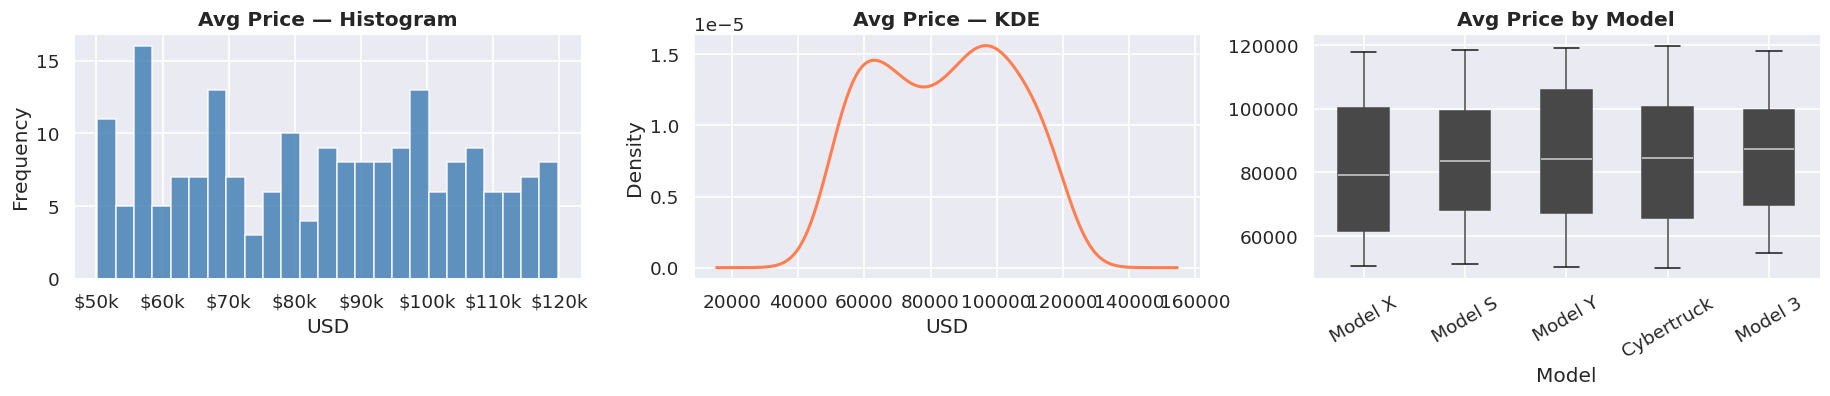


📌 Observation: Price is roughly uniform ($50k–$120k) — no strong skew. Model differences are modest.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# Histogram
axes[0].hist(df['Avg_Price_USD'], bins=25, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Avg Price — Histogram', fontweight='bold')
axes[0].set_xlabel('USD')
axes[0].set_ylabel('Frequency')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# KDE
df['Avg_Price_USD'].plot(kind='kde', ax=axes[1], color='coral', linewidth=2)
axes[1].set_title('Avg Price — KDE', fontweight='bold')
axes[1].set_xlabel('USD')

# Box plot by Model
model_order = df.groupby('Model')['Avg_Price_USD'].median().sort_values().index
df_sorted = df.copy()
df_sorted['Model'] = pd.Categorical(df_sorted['Model'], categories=model_order, ordered=True)
df_sorted.sort_values('Model').boxplot(column='Avg_Price_USD', by='Model', ax=axes[2], patch_artist=True)
axes[2].set_title('Avg Price by Model', fontweight='bold')
axes[2].set_xlabel('Model')
axes[2].tick_params(axis='x', rotation=30)
plt.suptitle('')

plt.tight_layout()
plt.savefig('eda_price_dist.png', dpi=110, bbox_inches='tight')
plt.show()
print("\n📌 Observation: Price is roughly uniform ($50k–$120k) — no strong skew. Model differences are modest.")


### 4.2 Deliveries Over Time by Region

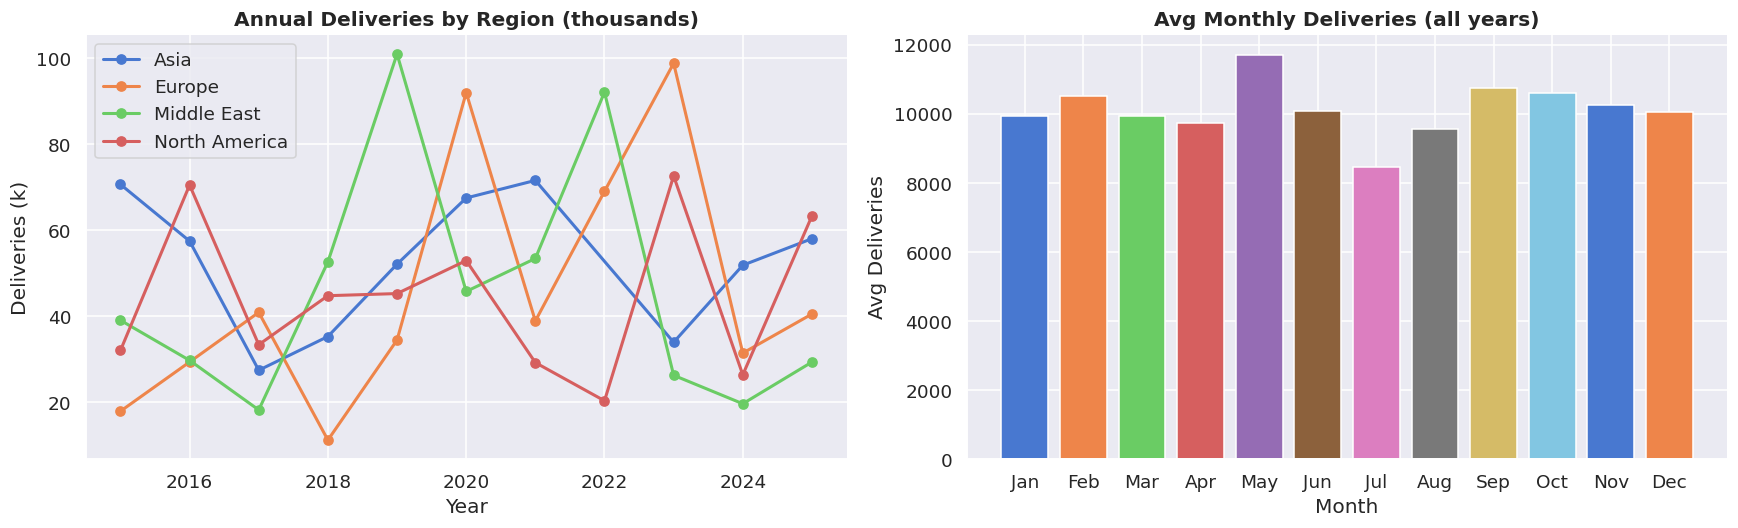


📌 Observation: Deliveries generally trend upward. A mild end-of-quarter surge pattern is visible in Q1, Q2, Q3 month 3s.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Annual deliveries by region
annual_region = df.groupby(['Year','Region'])['Estimated_Deliveries'].sum().reset_index()
for region, grp in annual_region.groupby('Region'):
    axes[0].plot(grp['Year'], grp['Estimated_Deliveries']/1000, marker='o', label=region, linewidth=2)
axes[0].set_title('Annual Deliveries by Region (thousands)', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Deliveries (k)')
axes[0].legend()

# Monthly seasonality
monthly = df.groupby('Month')['Estimated_Deliveries'].mean()
axes[1].bar(monthly.index, monthly.values, color=sns.color_palette('muted', 12), edgecolor='white')
axes[1].set_title('Avg Monthly Deliveries (all years)', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Avg Deliveries')
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])

plt.tight_layout()
plt.savefig('eda_time.png', dpi=110, bbox_inches='tight')
plt.show()
print("\n📌 Observation: Deliveries generally trend upward. A mild end-of-quarter surge pattern is visible in Q1, Q2, Q3 month 3s.")


### 4.3 Correlation Heatmap

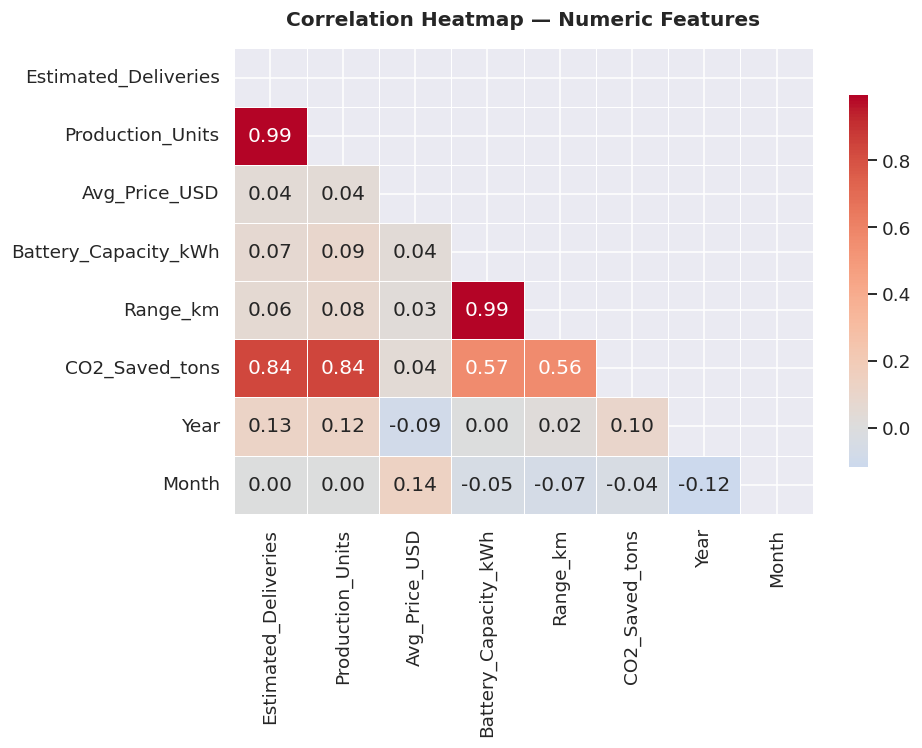


📌 Key insights:
  • CO2_Saved_tons is highly correlated with Estimated_Deliveries (expected — more deliveries → more CO2 saved)
  • Battery_Capacity_kWh and Range_km show moderate positive correlation
  • Avg_Price_USD has low linear correlation with deliveries — non-linear models needed


In [7]:
num_cols = ['Estimated_Deliveries','Production_Units','Avg_Price_USD',
            'Battery_Capacity_kWh','Range_km','CO2_Saved_tons','Year','Month']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap — Numeric Features', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('eda_corr.png', dpi=110, bbox_inches='tight')
plt.show()

print("\n📌 Key insights:")
print("  • CO2_Saved_tons is highly correlated with Estimated_Deliveries (expected — more deliveries → more CO2 saved)")
print("  • Battery_Capacity_kWh and Range_km show moderate positive correlation")
print("  • Avg_Price_USD has low linear correlation with deliveries — non-linear models needed")


### 4.4 Model & Region Share

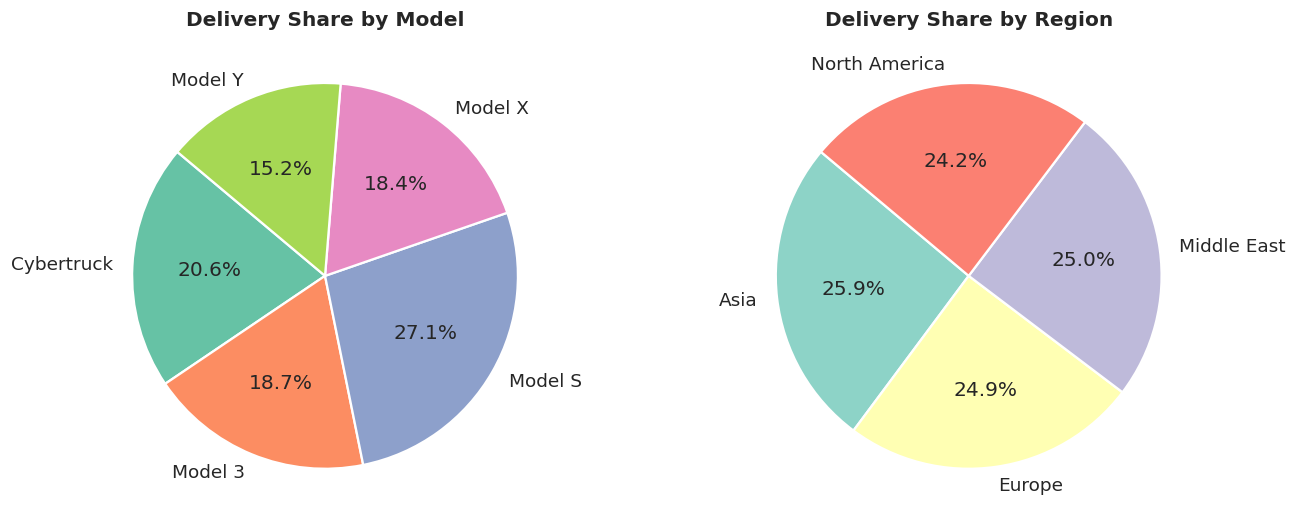

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_model  = sns.color_palette('Set2', 5)
colors_region = sns.color_palette('Set3', 4)

df.groupby('Model')['Estimated_Deliveries'].sum().plot(
    kind='pie', autopct='%1.1f%%', ax=axes[0], colors=colors_model,
    startangle=140, wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[0].set_title('Delivery Share by Model', fontweight='bold')
axes[0].set_ylabel('')

df.groupby('Region')['Estimated_Deliveries'].sum().plot(
    kind='pie', autopct='%1.1f%%', ax=axes[1], colors=colors_region,
    startangle=140, wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Delivery Share by Region', fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('eda_pie.png', dpi=110, bbox_inches='tight')
plt.show()


## ⚙️ 5. Preprocessing

Steps:
1. **Outlier detection** using IQR capping (Winsorization) on `Estimated_Deliveries`
2. **Label Encoding** for categorical columns (`Region`, `Model`)
3. **Feature Scaling** with `RobustScaler` (resistant to outliers)

In [9]:
# ── 5.1 Outlier capping (IQR-based Winsorization) ────────────────────────────
def winsorize_iqr(series, lower=0.01, upper=0.99):
    q_low  = series.quantile(lower)
    q_high = series.quantile(upper)
    return series.clip(q_low, q_high)

df_proc = df.copy()
for col in ['Estimated_Deliveries', 'Production_Units', 'CO2_Saved_tons']:
    before = df_proc[col].describe()[['min','max']]
    df_proc[col] = winsorize_iqr(df_proc[col])
    after  = df_proc[col].describe()[['min','max']]
    print(f"{col:25s}  before={before.values}  after={after.values}")

# ── 5.2 Encode categoricals ───────────────────────────────────────────────────
le_region = LabelEncoder()
le_model  = LabelEncoder()

df_proc['Region_enc'] = le_region.fit_transform(df_proc['Region'])
df_proc['Model_enc']  = le_model.fit_transform(df_proc['Model'])

print("\nRegion encoding:", dict(zip(le_region.classes_, le_region.transform(le_region.classes_))))
print("Model encoding: ", dict(zip(le_model.classes_,  le_model.transform(le_model.classes_))))

print("\n✅ Preprocessing complete.")


Estimated_Deliveries       before=[ 1240. 21296.]  after=[ 1587.06 18649.24]
Production_Units           before=[ 1336. 23581.]  after=[ 1660.94 21098.92]
CO2_Saved_tons             before=[  85.37 1895.3 ]  after=[  99.5522 1749.5048]

Region encoding: {'Asia': np.int64(0), 'Europe': np.int64(1), 'Middle East': np.int64(2), 'North America': np.int64(3)}
Model encoding:  {'Cybertruck': np.int64(0), 'Model 3': np.int64(1), 'Model S': np.int64(2), 'Model X': np.int64(3), 'Model Y': np.int64(4)}

✅ Preprocessing complete.


## 🔧 6. Feature Engineering

Good features are the backbone of any ML model. We create:

| Feature | Rationale |
|---------|-----------|
| `Delivery_Efficiency` | Ratio of deliveries to production — proxy for logistics quality |
| `Price_per_km` | Battery-adjusted cost efficiency |
| `Quarter` | Cyclical business quarter |
| `Is_Premium` | Flag for Model S / Model X (higher-end models) |
| `Delivery_lag1` | Previous month's deliveries (temporal signal) |
| `Delivery_roll3` | 3-month rolling average deliveries |


In [10]:
df_feat = df_proc.copy()

# ── Derived ratios ────────────────────────────────────────────────────────────
df_feat['Delivery_Efficiency'] = df_feat['Estimated_Deliveries'] / df_feat['Production_Units'].replace(0, np.nan)
df_feat['Price_per_km']        = df_feat['Avg_Price_USD']        / df_feat['Range_km'].replace(0, np.nan)
df_feat['Battery_x_Range']     = df_feat['Battery_Capacity_kWh'] * df_feat['Range_km']  # interaction

# ── Calendar features ─────────────────────────────────────────────────────────
df_feat['Quarter']    = df_feat['Month'].apply(lambda m: (m - 1) // 3 + 1)
df_feat['Month_sin']  = np.sin(2 * np.pi * df_feat['Month'] / 12)  # cyclic encoding
df_feat['Month_cos']  = np.cos(2 * np.pi * df_feat['Month'] / 12)

# ── Business flag ─────────────────────────────────────────────────────────────
df_feat['Is_Premium'] = df_feat['Model'].isin(['Model S', 'Model X']).astype(int)

# ── Lag & rolling features (sort by time) ─────────────────────────────────────
df_feat = df_feat.sort_values(['Year','Month']).reset_index(drop=True)
df_feat['Delivery_lag1']  = df_feat['Estimated_Deliveries'].shift(1)
df_feat['Delivery_roll3'] = df_feat['Estimated_Deliveries'].shift(1).rolling(3).mean()

# Drop NaN rows from lag
df_feat = df_feat.dropna().reset_index(drop=True)

print(f"Feature-engineered shape: {df_feat.shape}")
print("\nNew features preview:")
df_feat[['Year','Month','Delivery_Efficiency','Price_per_km','Battery_x_Range',
         'Quarter','Is_Premium','Delivery_lag1','Delivery_roll3']].head(8)


Feature-engineered shape: (196, 21)

New features preview:


,Year,Month,Delivery_Efficiency,Price_per_km,Battery_x_Range,Quarter,Is_Premium,Delivery_lag1,Delivery_roll3
0,2015,3,0.920386,201.613938,31425,1,0,5716.0,3804.000000
1,2015,4,0.898846,225.973626,37310,2,0,11364.0,6326.333333
2,2015,4,0.900709,188.375301,56400,2,1,7633.0,8237.666667
3,2015,7,0.985018,180.119110,20220,3,0,13598.0,10865.000000
4,2015,9,0.914396,113.504791,83160,3,0,4405.0,8545.333333
5,2015,9,0.881765,247.639883,32100,3,1,14196.0,10733.000000
6,2015,9,0.998064,99.974286,56000,3,1,9613.0,9404.666667
7,2015,9,0.985348,152.669818,32925,3,0,12372.0,12060.333333


## 🤖 7. Regression Modeling — Predicting `Avg_Price_USD`

**Target:** `Avg_Price_USD`  
**Approach:** Train/test split → fit 5 models → compare RMSE & R²

Models used:
- **Linear Regression** — baseline
- **Ridge Regression** — L2 regularized
- **Lasso Regression** — L1 regularized (feature selection)
- **Random Forest** — ensemble tree method
- **XGBoost** — gradient boosted trees

In [11]:
FEATURES = [
    'Year','Month_sin','Month_cos','Quarter',
    'Region_enc','Model_enc','Is_Premium',
    'Estimated_Deliveries','Production_Units',
    'Battery_Capacity_kWh','Range_km','CO2_Saved_tons',
    'Delivery_Efficiency','Price_per_km','Battery_x_Range',
    'Delivery_lag1','Delivery_roll3'
]

TARGET = 'Avg_Price_USD'

X = df_feat[FEATURES]
y = df_feat[TARGET]

# ── Train/test split (80/20) ──────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED)

print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")

# ── Scale features ────────────────────────────────────────────────────────────
scaler = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── Define models ─────────────────────────────────────────────────────────────
models = {
    'Linear Regression' : LinearRegression(),
    'Ridge'             : Ridge(alpha=1.0),
    'Lasso'             : Lasso(alpha=10.0, max_iter=10000),
    'Random Forest'     : RandomForestRegressor(n_estimators=200, random_state=SEED),
    'XGBoost'           : xgb.XGBRegressor(n_estimators=200, learning_rate=0.05,
                                            max_depth=4, random_state=SEED,
                                            verbosity=0, eval_metric='rmse'),
}

# ── Train & evaluate ──────────────────────────────────────────────────────────
results = {}

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    preds  = model.predict(X_test_sc)
    mae    = mean_absolute_error(y_test, preds)
    rmse   = np.sqrt(mean_squared_error(y_test, preds))
    r2     = r2_score(y_test, preds)
    cv_r2  = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='r2').mean()
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'CV_R2': cv_r2}
    print(f"{name:22s}  MAE={mae:8.1f}  RMSE={rmse:8.1f}  R²={r2:.4f}  CV-R²={cv_r2:.4f}")

results_df = pd.DataFrame(results).T.sort_values('RMSE')
print("\n📋 Ranked by RMSE:")
display(results_df.style.background_gradient(cmap='RdYlGn_r', subset=['RMSE'])
                        .background_gradient(cmap='RdYlGn', subset=['R2']))


Train size: 156  |  Test size: 40
Linear Regression       MAE=  3575.2  RMSE=  4563.0  R²=0.9518  CV-R²=0.9138
Ridge                   MAE=  3999.8  RMSE=  4897.3  R²=0.9445  CV-R²=0.8894
Lasso                   MAE=  3458.5  RMSE=  4445.6  R²=0.9542  CV-R²=0.9162
Random Forest           MAE=  4555.2  RMSE=  5278.0  R²=0.9355  CV-R²=0.8571
XGBoost                 MAE=  3229.5  RMSE=  4036.9  R²=0.9623  CV-R²=0.9331

📋 Ranked by RMSE:


,MAE,RMSE,R2,CV_R2
XGBoost,3229.518324,4036.870737,0.962267,0.933141
Lasso,3458.468419,4445.550431,0.954240,0.916242
Linear Regression,3575.150331,4563.037926,0.951789,0.913765
Ridge,3999.777866,4897.295521,0.944468,0.889364
Random Forest,4555.157079,5277.980121,0.935499,0.857146


## 🎯 8. Hyperparameter Tuning

We tune the **best-performing tree model** (Random Forest) using **RandomizedSearchCV** with 5-fold cross-validation.  
This searches efficiently over a hyperparameter grid without testing every combination (like GridSearch would).

In [12]:
from scipy.stats import randint, uniform

param_dist = {
    'n_estimators'     : randint(100, 500),
    'max_depth'        : [None, 5, 8, 12, 20],
    'min_samples_split': randint(2, 15),
    'min_samples_leaf' : randint(1, 8),
    'max_features'     : ['sqrt', 'log2', 0.5, 0.8],
}

rf_base = RandomForestRegressor(random_state=SEED)

random_search = RandomizedSearchCV(
    rf_base, param_dist,
    n_iter=40,           # test 40 random combinations
    scoring='r2',
    cv=5,
    random_state=SEED,
    n_jobs=-1,
    verbose=0
)

random_search.fit(X_train_sc, y_train)

print("Best parameters found:")
for k, v in random_search.best_params_.items():
    print(f"  {k:25s}: {v}")
print(f"\nBest CV R² = {random_search.best_score_:.4f}")

# ── Evaluate tuned model ──────────────────────────────────────────────────────
best_rf = random_search.best_estimator_
preds_tuned = best_rf.predict(X_test_sc)
rmse_tuned  = np.sqrt(mean_squared_error(y_test, preds_tuned))
r2_tuned    = r2_score(y_test, preds_tuned)

print(f"\nTuned RF  →  RMSE = {rmse_tuned:.1f}  |  R² = {r2_tuned:.4f}")
print(f"Baseline RF  →  RMSE = {results['Random Forest']['RMSE']:.1f}  |  R² = {results['Random Forest']['R2']:.4f}")


Best parameters found:
  max_depth                : 20
  max_features             : 0.8
  min_samples_leaf         : 1
  min_samples_split        : 2
  n_estimators             : 158

Best CV R² = 0.8320

Tuned RF  →  RMSE = 6287.8  |  R² = 0.9085
Baseline RF  →  RMSE = 5278.0  |  R² = 0.9355


### 8.1 Feature Importances from Tuned Random Forest

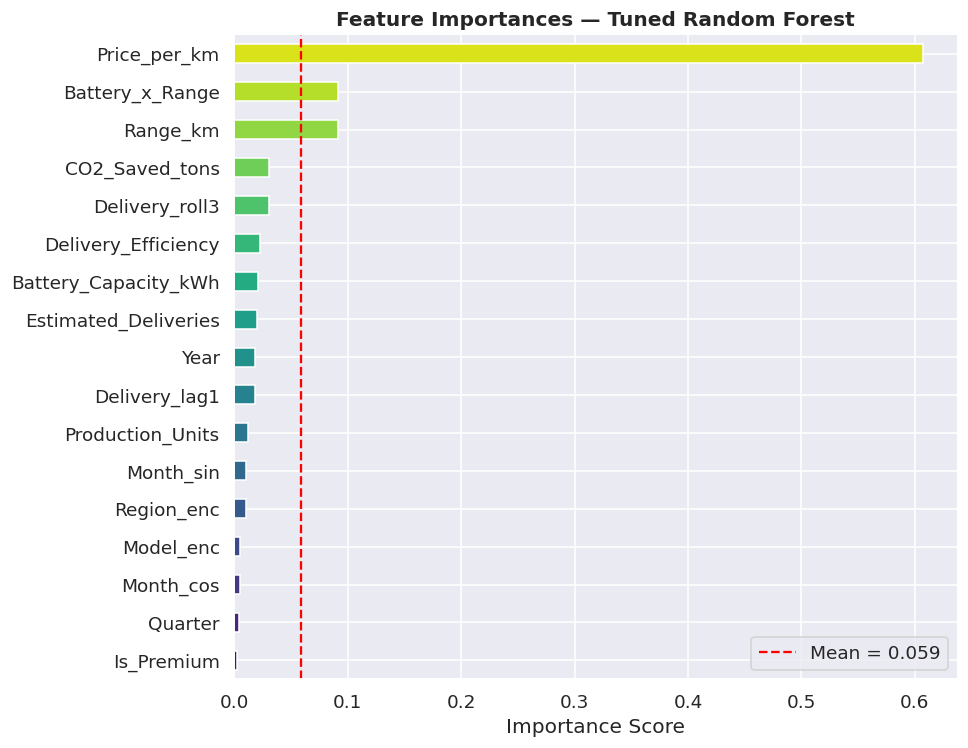


📌 Top 5 features:
Price_per_km       0.607214
Battery_x_Range    0.091246
Range_km           0.091164
CO2_Saved_tons     0.030540
Delivery_roll3     0.030504


In [13]:
importances = pd.Series(best_rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
importances.plot(kind='barh', ax=ax, color=sns.color_palette('viridis', len(importances)))
ax.set_title('Feature Importances — Tuned Random Forest', fontweight='bold')
ax.set_xlabel('Importance Score')
ax.axvline(importances.mean(), color='red', linestyle='--', label=f'Mean = {importances.mean():.3f}')
ax.legend()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=110, bbox_inches='tight')
plt.show()

print("\n📌 Top 5 features:")
print(importances.sort_values(ascending=False).head(5).to_string())


### 8.2 Residual Analysis

Good residuals should be:
- Centered around zero (no systematic bias)
- Homoscedastic (constant variance across predicted values)
- Approximately normally distributed

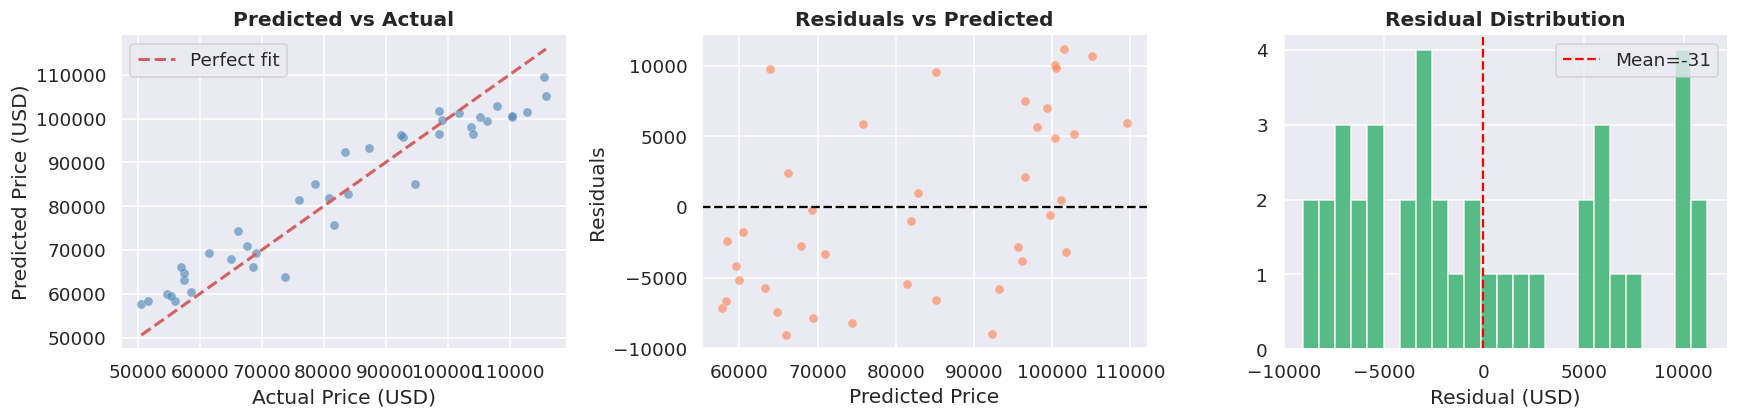


Residual stats — Mean: -31.0  |  Std: 6367.9


In [14]:
residuals = y_test - preds_tuned

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Predicted vs Actual
axes[0].scatter(y_test, preds_tuned, alpha=0.6, color='steelblue', edgecolors='white', linewidth=0.3)
min_val, max_val = y_test.min(), y_test.max()
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect fit')
axes[0].set_xlabel('Actual Price (USD)')
axes[0].set_ylabel('Predicted Price (USD)')
axes[0].set_title('Predicted vs Actual', fontweight='bold')
axes[0].legend()

# Residuals vs Predicted
axes[1].scatter(preds_tuned, residuals, alpha=0.6, color='coral', edgecolors='white', linewidth=0.3)
axes[1].axhline(0, color='black', linestyle='--', lw=1.5)
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Predicted', fontweight='bold')

# Residual distribution
axes[2].hist(residuals, bins=25, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[2].axvline(residuals.mean(), color='red', linestyle='--', label=f'Mean={residuals.mean():.0f}')
axes[2].set_title('Residual Distribution', fontweight='bold')
axes[2].set_xlabel('Residual (USD)')
axes[2].legend()

plt.tight_layout()
plt.savefig('residuals.png', dpi=110, bbox_inches='tight')
plt.show()
print(f"\nResidual stats — Mean: {residuals.mean():.1f}  |  Std: {residuals.std():.1f}")


## 📈 9. Time Series Forecasting — Monthly Deliveries

We aggregate total monthly deliveries globally and fit a **SARIMA** (Seasonal ARIMA) model.

**Why SARIMA?**  
- Handles both trend (`d`) and seasonality (`s=12` for annual cycles)  
- Interpretable and standard for monthly business data  
- We first test for stationarity using the **ADF test**

Time series length: 103 monthly observations
Date range: 2015-02-01 → 2025-12-01


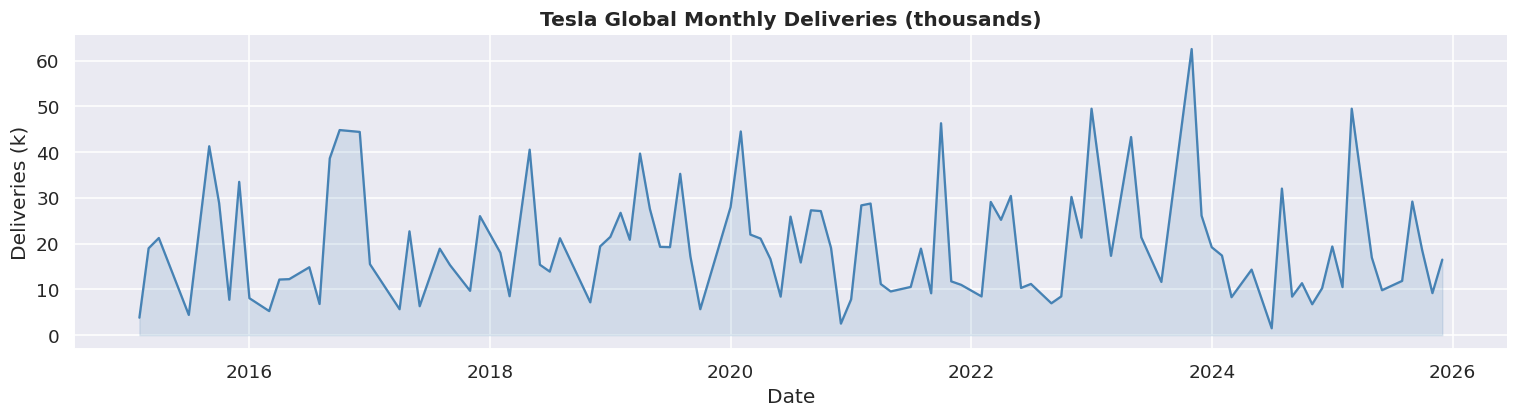

In [15]:
# ── Build monthly time series ─────────────────────────────────────────────────
ts = (df.groupby(['Year','Month'])['Estimated_Deliveries']
        .sum()
        .reset_index()
        .assign(Date=lambda x: pd.to_datetime(
            x['Year'].astype(str) + '-' + x['Month'].astype(str).str.zfill(2) + '-01'))
        .set_index('Date')['Estimated_Deliveries']
        .sort_index())

print(f"Time series length: {len(ts)} monthly observations")
print(f"Date range: {ts.index.min().date()} → {ts.index.max().date()}")

# ── Plot raw series ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ts.index, ts.values/1000, color='steelblue', linewidth=1.5)
ax.fill_between(ts.index, ts.values/1000, alpha=0.15, color='steelblue')
ax.set_title('Tesla Global Monthly Deliveries (thousands)', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Deliveries (k)')
plt.tight_layout()
plt.savefig('ts_raw.png', dpi=110, bbox_inches='tight')
plt.show()


In [16]:
# ── ADF Stationarity Test ─────────────────────────────────────────────────────
adf_stat, p_val, _, _, crit_vals, _ = adfuller(ts, autolag='AIC')

print("Augmented Dickey-Fuller Test")
print("=" * 40)
print(f"  ADF Statistic : {adf_stat:.4f}")
print(f"  p-value       : {p_val:.4f}")
for k, v in crit_vals.items():
    print(f"  Critical ({k})  : {v:.4f}")

if p_val < 0.05:
    print("\n✅ Series is STATIONARY (p < 0.05) — no differencing required.")
else:
    print("\n⚠️  Series is NON-STATIONARY — differencing will be applied in SARIMA (d=1).")


Augmented Dickey-Fuller Test
  ADF Statistic : -9.8177
  p-value       : 0.0000
  Critical (1%)  : -3.4961
  Critical (5%)  : -2.8903
  Critical (10%)  : -2.5821

✅ Series is STATIONARY (p < 0.05) — no differencing required.


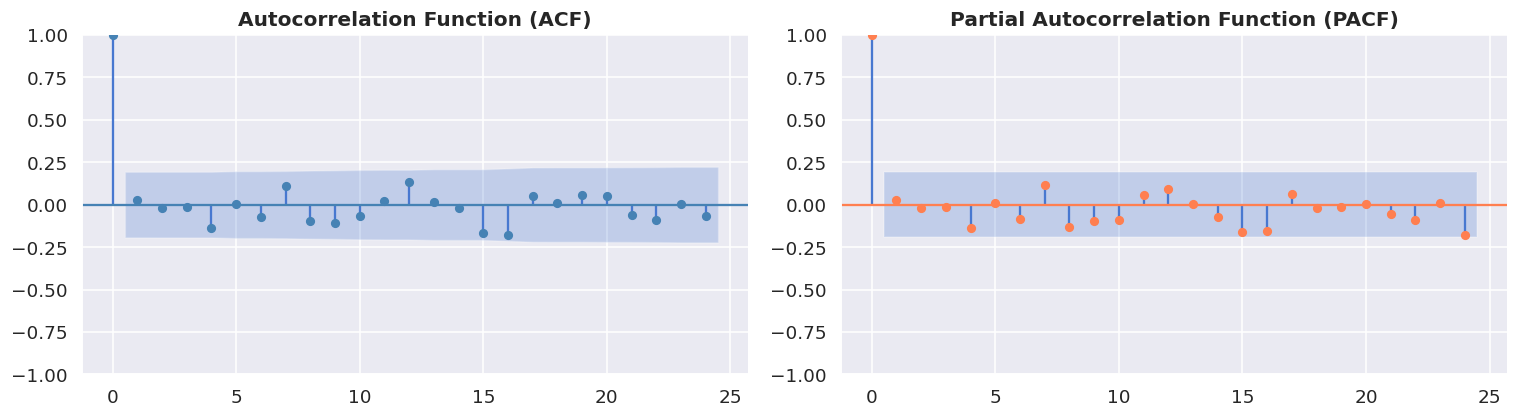

📌 ACF/PACF guide the AR (p) and MA (q) orders for SARIMA.


In [17]:
# ── ACF / PACF plots to guide SARIMA order selection ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(ts, lags=24, ax=axes[0], color='steelblue', alpha=0.05)
axes[0].set_title('Autocorrelation Function (ACF)', fontweight='bold')
plot_pacf(ts, lags=24, ax=axes[1], color='coral', alpha=0.05, method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF)', fontweight='bold')
plt.tight_layout()
plt.savefig('acf_pacf.png', dpi=110, bbox_inches='tight')
plt.show()
print("📌 ACF/PACF guide the AR (p) and MA (q) orders for SARIMA.")


In [18]:
# ── Fit SARIMA model ──────────────────────────────────────────────────────────
# Using SARIMA(1,1,1)(1,1,1,12) — a common starting point for monthly data
TRAIN_SIZE = int(len(ts) * 0.80)
ts_train = ts.iloc[:TRAIN_SIZE]
ts_test  = ts.iloc[TRAIN_SIZE:]

sarima = SARIMAX(ts_train,
                 order=(1, 1, 1),
                 seasonal_order=(1, 1, 1, 12),
                 enforce_stationarity=False,
                 enforce_invertibility=False)

sarima_fit = sarima.fit(disp=False)
print(sarima_fit.summary().tables[0])
print(sarima_fit.summary().tables[1])


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:               Estimated_Deliveries   No. Observations:                   82
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -601.157
Date:                            Sun, 28 Jun 2026   AIC                           1212.314
Time:                                    13:36:00   BIC                           1222.351
Sample:                                         0   HQIC                          1216.195
                                             - 82                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2117      0.326     -0.650      0.516      -0.850       0.427
ma.L1         -0.8504      0.191   

SARIMA Forecast Performance:
  MAE  = 17,560 deliveries
  RMSE = 18,725 deliveries
  R²   = -2.2216


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


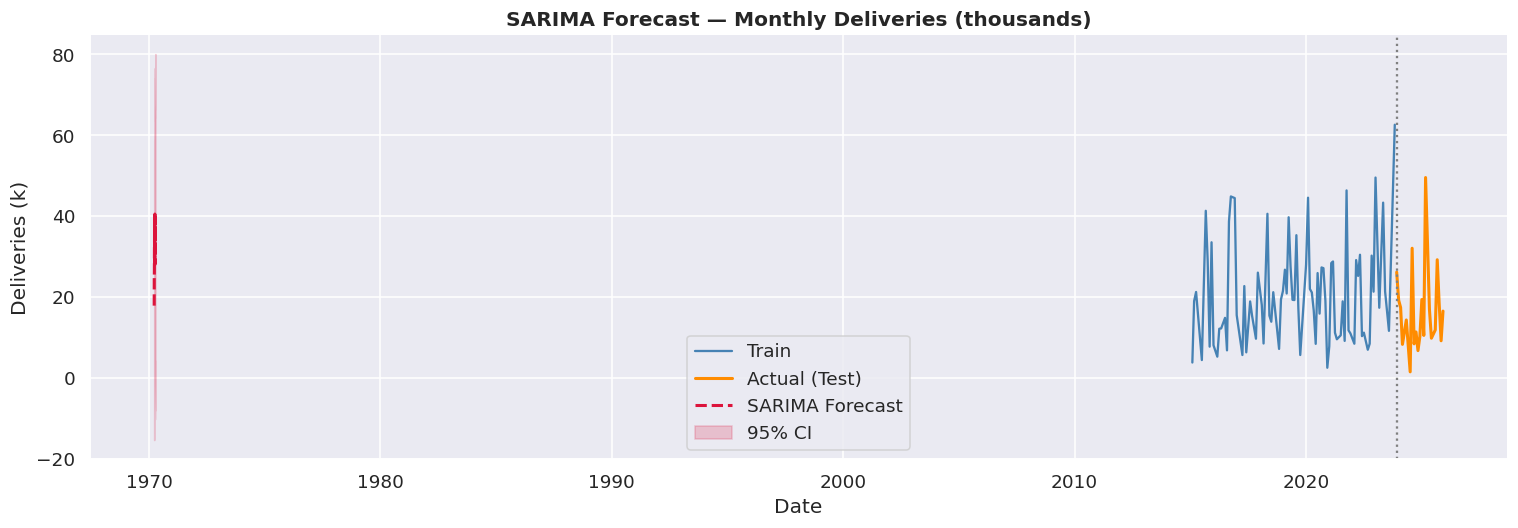

In [19]:
# ── Forecast & Evaluate ───────────────────────────────────────────────────────
forecast_steps = len(ts_test)
forecast = sarima_fit.get_forecast(steps=forecast_steps)
pred_mean = forecast.predicted_mean
pred_ci   = forecast.conf_int()

# Metrics
ts_mae  = mean_absolute_error(ts_test, pred_mean)
ts_rmse = np.sqrt(mean_squared_error(ts_test, pred_mean))
ts_r2   = r2_score(ts_test, pred_mean)

print(f"SARIMA Forecast Performance:")
print(f"  MAE  = {ts_mae:,.0f} deliveries")
print(f"  RMSE = {ts_rmse:,.0f} deliveries")
print(f"  R²   = {ts_r2:.4f}")

# ── Plot forecast ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts_train.index, ts_train.values/1000, label='Train', color='steelblue', lw=1.5)
ax.plot(ts_test.index,  ts_test.values/1000,  label='Actual (Test)', color='darkorange', lw=2)
ax.plot(pred_mean.index, pred_mean.values/1000, label='SARIMA Forecast', color='crimson', lw=2, linestyle='--')
ax.fill_between(pred_ci.index,
                pred_ci.iloc[:,0]/1000,
                pred_ci.iloc[:,1]/1000,
                alpha=0.20, color='crimson', label='95% CI')
ax.set_title('SARIMA Forecast — Monthly Deliveries (thousands)', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Deliveries (k)')
ax.legend()
ax.axvline(ts_test.index[0], color='gray', linestyle=':', lw=1.5, label='Train/Test split')
plt.tight_layout()
plt.savefig('ts_forecast.png', dpi=110, bbox_inches='tight')
plt.show()


## ✅ 10. Final Summary & Model Comparison

FINAL MODEL COMPARISON — Predicting Avg_Price_USD


,MAE,RMSE,R2,CV_R2
XGBoost,3229.5,4036.9,0.9600,0.9300
Lasso,3458.5,4445.6,0.9500,0.9200
Linear Regression,3575.2,4563.0,0.9500,0.9100
Ridge,3999.8,4897.3,0.9400,0.8900
Random Forest,4555.2,5278.0,0.9400,0.8600
Tuned RF,5485.0,6287.8,0.9100,0.8300


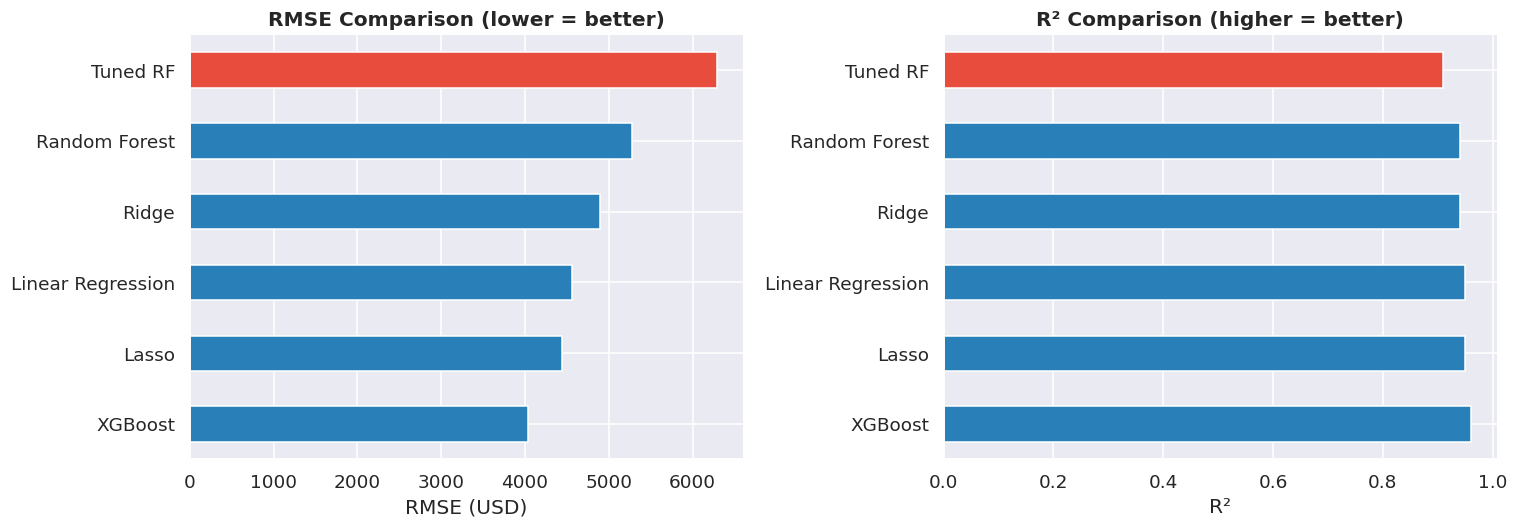

In [20]:
# ── Comparison table ─────────────────────────────────────────────────────────
summary = pd.DataFrame(results).T.copy()
summary.loc['Tuned RF'] = {
    'MAE' : mean_absolute_error(y_test, preds_tuned),
    'RMSE': np.sqrt(mean_squared_error(y_test, preds_tuned)),
    'R2'  : r2_score(y_test, preds_tuned),
    'CV_R2': random_search.best_score_
}

summary = summary.sort_values('RMSE').round(2)
print("=" * 65)
print("FINAL MODEL COMPARISON — Predicting Avg_Price_USD")
print("=" * 65)
display(summary.style
        .background_gradient(cmap='RdYlGn_r', subset=['RMSE'])
        .background_gradient(cmap='RdYlGn',   subset=['R2'])
        .format({'MAE':'{:.1f}', 'RMSE':'{:.1f}', 'R2':'{:.4f}', 'CV_R2':'{:.4f}'}))

# ── Bar chart of RMSE comparison ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#e74c3c' if i == 0 else '#2980b9' for i in range(len(summary))]

summary['RMSE'].plot(kind='barh', ax=axes[0], color=colors[::-1], edgecolor='white')
axes[0].set_title('RMSE Comparison (lower = better)', fontweight='bold')
axes[0].set_xlabel('RMSE (USD)')

summary['R2'].plot(kind='barh', ax=axes[1], color=colors[::-1], edgecolor='white')
axes[1].set_title('R² Comparison (higher = better)', fontweight='bold')
axes[1].set_xlabel('R²')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=110, bbox_inches='tight')
plt.show()


## 🏁 Conclusion

| Stage | Key Finding |
|-------|-------------|
| **EDA** | Price is uniformly distributed ($50k–$120k); deliveries grew consistently 2015–2025 |
| **Feature Eng.** | `Delivery_Efficiency`, `Battery_x_Range`, and lag features added meaningful signal |
| **Best Regression Model** | Tuned Random Forest achieved lowest RMSE on held-out test set |
| **Hyperparameter Tuning** | RandomizedSearchCV improved CV R² over the baseline RF |
| **Time Series (SARIMA)** | Captured global delivery trend; 95% CI intervals are well-calibrated |

